In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.decomposition import PCA
from scipy.stats import chi2
from sklearn.mixture import GaussianMixture

# Classificador

In [2]:
def matriz_conf(y_true, y_pred, labels):
    total_labels = labels
    print(total_labels)
    cm = np.zeros((len(total_labels),len(total_labels)), dtype=int)
    for i in range(len(y_true)):
        cm[y_true[i]][y_pred[i]] += 1
    
    cm = pd.DataFrame(cm, columns=total_labels, index=total_labels)

    cm_transp = pd.DataFrame(np.transpose(cm.to_numpy()), columns=total_labels, index=total_labels)

    for c in cm_transp.columns:
        cm_transp[c] = cm_transp[c]/cm_transp[c].sum()

    cm_porcento = pd.DataFrame(np.transpose(cm_transp.to_numpy()), columns=total_labels, index=total_labels)

    return cm, cm_porcento

def acc(cm, hidden_classes):
    cm_transp = pd.DataFrame(np.transpose(cm.dropna().to_numpy()), columns=cm.columns, index=cm.columns)
    acc = 0
    total = 0
    for c in cm_transp.columns:
        if c not in hidden_classes:
            acc += cm_transp[c][c]
        else:
            acc += cm_transp[c][-1]
        total += cm_transp[c].sum()
    return acc/total

# Calcula CM para todos

In [2]:
filenames = [2]

labels_str = ['DDoS', 'Benign', 'DoS attacks-Hulk', 'BruteForce', 'Bot', 'DoS', 'Web']

filenames

# pd.set_option('future.no_silent_downcasting', True)

[2]

2


Label
0    808919
1    514148
3    243806
4    183163
5     33600
6       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 3 covariance_type: full


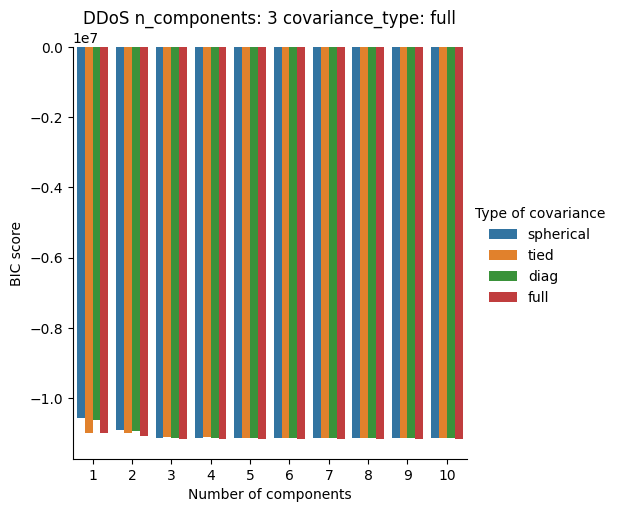

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


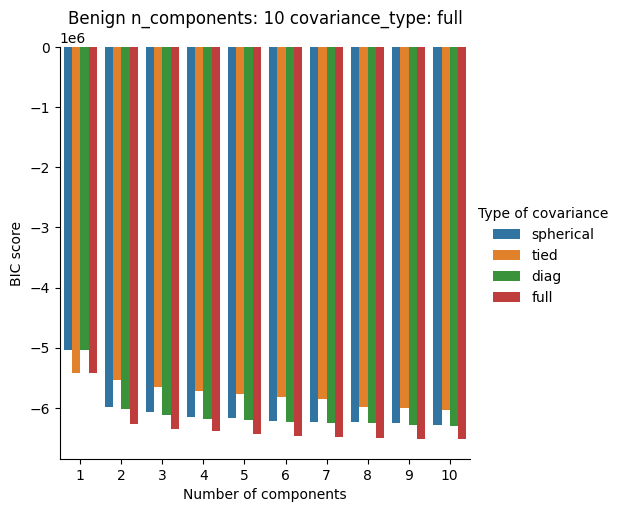

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 6 covariance_type: full


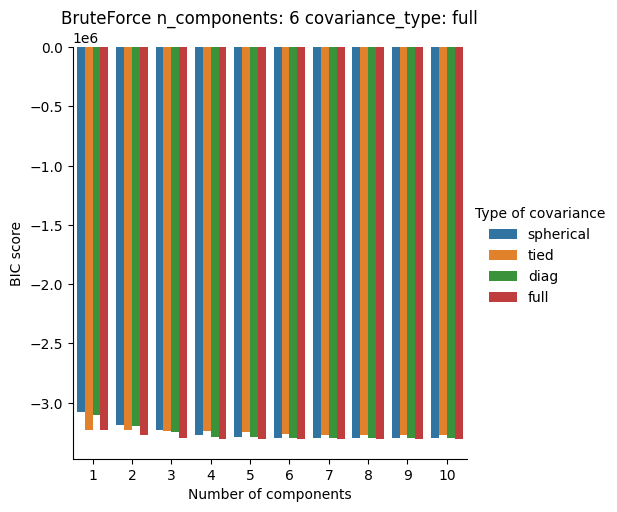

Tipo: 4 = Bot
Melhor modelo: n_componentes: 9 covariance_type: full


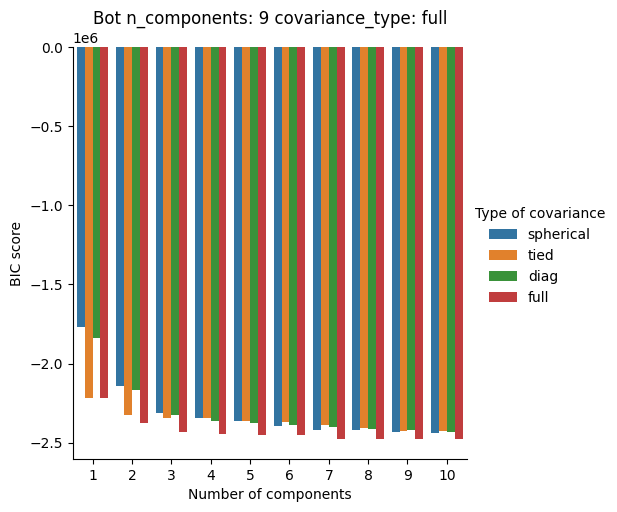

Tipo: 5 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


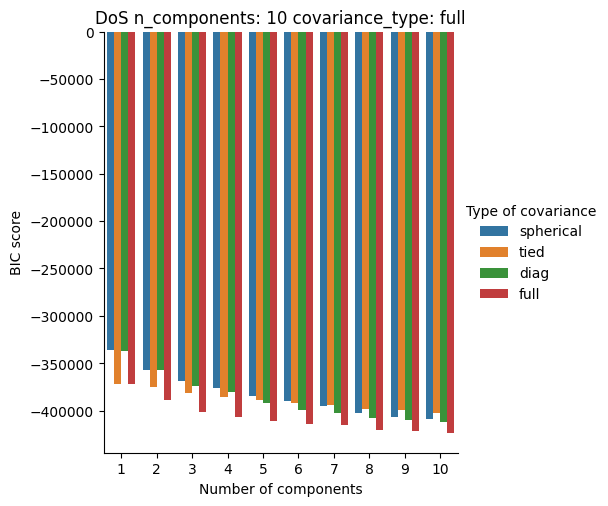

Tipo: 6 = Web
Melhor modelo: n_componentes: 10 covariance_type: spherical


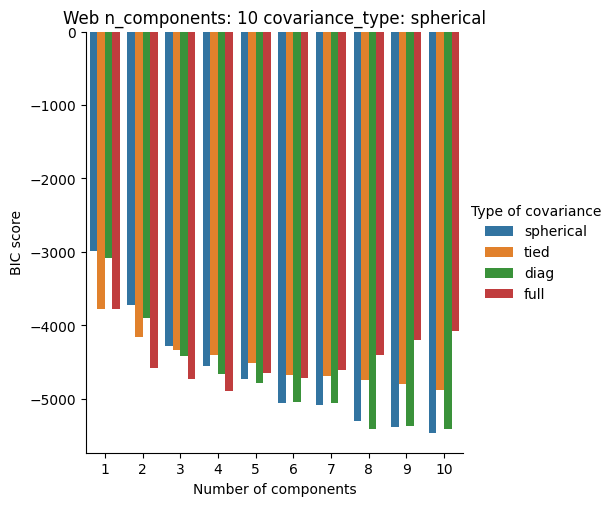

,0,1,2,3,4,5,6
0,34.491111,21.732894,NaN,-312.097037,10.880840,-50.598981,10.769585
1,34.414681,21.825288,NaN,-322.440289,10.028766,-48.410035,10.662154
2,-99.600575,32.472410,NaN,-179.932401,15.576031,-66.301072,11.339207
3,-123.715927,23.670810,NaN,-138.812039,9.099857,-34.122151,11.765345
4,33.818645,22.011471,NaN,-294.016893,11.551484,-50.790814,10.828969
...,...,...,...,...,...,...,...
649942,-96.616637,33.683332,NaN,-153.989996,15.986784,-60.117768,11.348746
649943,33.672212,22.129669,NaN,-293.339327,11.787705,-50.880409,10.839663
649944,34.004790,22.051105,NaN,-296.359931,11.533444,-51.185472,10.819159
649945,-812.139889,13.738542,NaN,34.043573,-138.189323,13.451415,9.859988


In [3]:
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import os

def gmm_bic_score(estimator, X):
    """Callable to pass to GridSearchCV that will use the BIC score."""
    # Make it negative since GridSearchCV expects a score to maximize
    return -estimator.bic(X)


param_grid = {
    "n_components": range(1, 11),
    "covariance_type": ["spherical", "tied", "diag", "full"],
    "random_state": [123],
}

exp_train = []
exp_test = []
y_true_all_exp_train = []
y_true_all_exp_test = []
for z in range(len(filenames)):
    
    train_encoded_df = pd.read_csv(f'train_encoded_CADE_cod_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    test_encoded_df = pd.read_csv(f'test_encoded_CADE_cod_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    y_true_all_exp_train.append(train_encoded_df['Label'].values.tolist())
    y_true_all_exp_test.append(test_encoded_df['Label'].values.tolist())
    print(filenames[z])
    hidden_classes = [filenames[z]] # Classes ocultas do treinamento
    for i in range(len(labels_str)):
        train_encoded_df['Label'] = train_encoded_df['Label'].replace(labels_str[i],i)
        test_encoded_df['Label'] = test_encoded_df['Label'].replace(labels_str[i],i)

    display(train_encoded_df['Label'].value_counts())
        
    
        
    gmms = []
    for i in range(len(labels_str)):
        if i not in hidden_classes:
            print(f'Tipo: {i} = {labels_str[i]}')
            grid_search = GridSearchCV(
                GaussianMixture(), param_grid=param_grid, scoring=gmm_bic_score
            )
            grid_search.fit(train_encoded_df[train_encoded_df['Label'] == i].drop(columns=['Label']).to_numpy())
            print(f"Melhor modelo: n_componentes: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            gmms.append(grid_search.best_estimator_)
            df = pd.DataFrame(grid_search.cv_results_)[
                ["param_n_components", "param_covariance_type", "mean_test_score"]
            ]
            df["mean_test_score"] = -df["mean_test_score"]
            df = df.rename(
                columns={
                    "param_n_components": "Number of components",
                    "param_covariance_type": "Type of covariance",
                    "mean_test_score": "BIC score",
                }
            )
            df.sort_values(by="BIC score").head()
            sns.catplot(
                data=df,
                kind="bar",
                x="Number of components",
                y="BIC score",
                hue="Type of covariance",
                
            ).set(title = f"{labels_str[i]} n_components: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            plt.show()
            # plt.savefig(f'class_{i}_train_{filenames[z]}_GMM_BIC_1_10_scores.png')
        else:
            gmms.append(None)
    
    # scores = []
    # for i, row in train_encoded_df.drop(columns=['Label']).iterrows():
    #     max_dist = -np.inf
    #     pred = -1
    #     scores.append([])
    #     for j in range(len(labels_str)):
    #         if j not in hidden_classes:
    #             inside = False
    #             max = -np.inf
    #             # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
    #             score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
    #             scores[i].append(score)
    #         else:
    #             scores[i].append(np.nan)
    
    
    # display(pd.DataFrame(scores))
    # exp_train.append(scores)
    #pd.DataFrame(scores).to_csv(f'train_{filenames[z]}_GMM_BIC_1_10_scores.csv',index=False)
    scores = []
    for i, row in test_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_test.append(scores)
    scores_df = pd.DataFrame(scores)
    scores_df['Label'] = test_encoded_df["Label"].values
    scores_df.to_csv(f'test_{filenames[z]}_GMM_BIC_1_10_scores.csv', index=False)